In [267]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import matplotlib.pyplot as plt
from helper import load_stories_from_file

In [268]:
class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs)
        self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs=rngs)
    
    def __call__(self, x):
        seq_len = x.shape[1]
        positions = jnp.arange(seq_len)[None, :] #(1, seq_len)row_vector
        return self.token_emb(x) + self.pos_emb(positions)

In [269]:
# pip install jax

In [270]:
# !pip3.11 install --upgrade pip

In [271]:
# pip install flax

In [272]:
def causal_attention_mask(seq_len):
    return jnp.tril(jnp.ones((seq_len, seq_len)))
    

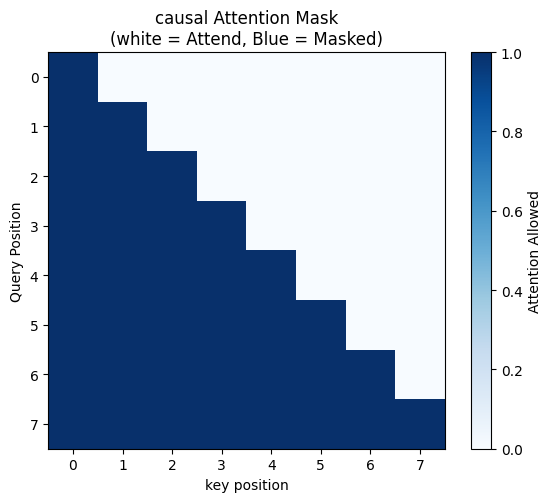

In [273]:
mask = causal_attention_mask(8)
plt.figure(figsize=(6,5))
plt.imshow(mask, cmap= 'Blues', interpolation='nearest')
plt.xlabel('key position')
plt.ylabel('Query Position')
plt.title('causal Attention Mask\n(white = Attend, Blue = Masked)')
plt.colorbar(label = 'Attention Allowed')
plt.tight_layout()
plt.show()

## Build the Transformer Block

In [274]:
class TransformerBlock(nnx.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):
        self.attention = nnx.MultiHeadAttention(
            num_heads=num_heads, 
            in_features=embed_dim,
            qkv_features=embed_dim,
            out_features=embed_dim,
            decode=False,
            rngs=rngs
        )
    def __call__(self, x, mask=None):
        attn_out = self.attention(x, mask = mask)
        x = x + attn_out
        return x




## Define the model configuration

In [275]:
class MiniGPT(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, num_heads, feed_forward_dim, num_transformer_blocks, *, rngs):
        self.maxlen=maxlen
        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim, rngs = rngs)
        self.transformer_blocks = nnx.List([
            TransformerBlock(embed_dim, num_heads, feed_forward_dim, rngs=rngs)
            for _ in range(num_transformer_blocks)
        ])
        self.output_layer = nnx.Linear(embed_dim, vocab_size, use_bias=False, rngs=rngs)
        
    def causal_attention_mask(self, seq_len):
        return jnp.tril(jnp.ones((seq_len, seq_len)))
    
    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        mask = self.causal_attention_mask(seq_len)
        x = self.embedding(token_ids)
        for block in self.transformer_blocks:
            x = block(x, mask=mask)
        logits = self.output_layer(x)
        return logits
            

## Final Model 

In [276]:
import tiktoken



In [277]:
# pip install transformers

In [278]:
from transformers import GPT2Tokenizer


In [279]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")


In [280]:
tokens = tokenizer.encode("Hello world")

In [281]:
tokens

[15496, 995]

In [282]:
tokenizer.vocab_size

50257

In [283]:
tokenizer.encode("cat")


[9246]

In [284]:
tokenizer.encode("Gaurav Jain")

[38, 2899, 615, 449, 391]

In [285]:
tokenizer.encode("Bharat")

[33, 9869, 265]

In [286]:
model = MiniGPT(
    maxlen=128,
    vocab_size=tokenizer.vocab_size,
    embed_dim=192,
    num_heads=6,
    feed_forward_dim = 512,
    num_transformer_blocks=6,
    rngs=nnx.Rngs(0)
)

In [287]:
# model

## Data Loading with Grain

In [288]:
import jax
import jax.numpy as jnp

In [289]:
# pip install grain

In [290]:
import grain

In [291]:
import grain.python as grain

In [292]:
import tiktoken

In [293]:
# pip install pathlib

In [294]:
import pathlib

In [295]:
from pathlib import Path

In [296]:
import optax

In [314]:
from helper import load_stories_from_file

In [346]:
# file_path = Path("TinyStories-1000.txt")
# file_path = '/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt'  
file_path = '/home/z005657m/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt'

In [347]:
print(file_path)

/home/z005657m/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt


In [340]:
import os

# Check current directory
print(os.getcwd())

# List files in current directory
print(os.listdir('.'))

# Search for the file
for root, dirs, files in os.walk('.'):
    for f in files:
        if 'TinyStories' in f:
            print(os.path.join(root, f))


/tmp
['data-gym-cache', 'gradio', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-upower.service-FQm3Mf', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-ModemManager.service-IhWici', 'small_checkpoint.orbax', '.X11-unix', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-resolved.service-Fd3O5e', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-colord.service-p5bUqj', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-timesyncd.service-fxmXij', '.ICE-unix', '.Test-unix', '.gradio', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-logind.service-5pf1cf', '.XIM-unix', '.font-unix', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-switcheroo-control.service-KdHfhi', 'snap-private-tmp', 'nmh_msg_bus.sock']


In [342]:
import os
print(os.getcwd())  

/tmp


In [343]:
import os
print(os.listdir('.'))

['data-gym-cache', 'gradio', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-upower.service-FQm3Mf', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-ModemManager.service-IhWici', 'small_checkpoint.orbax', '.X11-unix', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-resolved.service-Fd3O5e', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-colord.service-p5bUqj', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-timesyncd.service-fxmXij', '.ICE-unix', '.Test-unix', '.gradio', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-systemd-logind.service-5pf1cf', '.XIM-unix', '.font-unix', 'systemd-private-d917da28f12e46cfa180dc1ac78a73a9-switcheroo-control.service-KdHfhi', 'snap-private-tmp', 'nmh_msg_bus.sock']


In [344]:
import os
for root, dirs, files in os.walk('/'):
    for f in files:
        if 'TinyStories' in f:
            print(os.path.join(root, f))

/home/z005657m/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt
/home/z005657m/Gaurav_CLT/Transformer Architecture/.ipynb_checkpoints/TinyStories-1000-checkpoint.txt


In [345]:
import os
home = os.path.expanduser("~")
print(f"Home directory: {home}")
print(os.listdir(home))


Home directory: /home/z005657m
['.cache', '.bashrc', 'Gaurav_CLT', '.jupyter', '.config', 'small_checkpoint.orbax', '.local', '.ipynb_checkpoints', '.profile', '.keras', '.ipython', 'shared_groups', '.bash_logout', 'shared']


In [348]:
# file_path = Path("TinyStories-1000.txt")

with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
    data = f.read()
    stories = data.split('<|endoftext|>')

    print("First story (300 chars):\n")
    story = stories[0]
    print(story.strip()[:300], "...")

    print(f"\nTotal number of stories: {len(stories) - 1:,}")


First story (300 chars):

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.
Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and s ...

Total number of stories: 1,000


## Tokenizer

In [349]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

In [350]:


print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Special tokens: {tokenizer.all_special_tokens}")

Vocabulary size: 50,257
Special tokens: ['<|endoftext|>']


## Dataset Class

In [351]:
class StoryDataset:
    
    def __init__(self, stories, maxlen, tokenizer):
        self.stories = stories
        self.maxlen = maxlen
        self.tokenizer = tokenizer
        self.end_token = tokenizer.encode('<|endoftext|>', \
                        allowed_special={'<|endoftext|>'})[0]

    def __len__(self):
        return len(self.stories)

    def __getitem__(self, idx):
        story = self.stories[idx]
        tokens = self.tokenizer.encode(story, 
                                       allowed_special={'<|endoftext|>'})

        if len(tokens) > self.maxlen:
            tokens = tokens[:self.maxlen]
            
        tokens.extend([0] * (self.maxlen - len(tokens)))
        return tokens

## Build a data iterator

In [352]:
shuffled_sampler = grain.IndexSampler(
    num_records=10,
    shuffle=True,
    seed=42,
    shard_options=grain.NoSharding(),    
    num_epochs=1
)

def print_sampler_example(sampler, name):
    print(f"\n{name}")
    for i, idx in enumerate(sampler):
        print(f"Record {i}: {idx}")

print_sampler_example(shuffled_sampler, "Shuffled sampler")



Shuffled sampler
Record 0: RecordMetadata(index=0, record_key=8, rng=Generator(Philox))
Record 1: RecordMetadata(index=1, record_key=6, rng=Generator(Philox))
Record 2: RecordMetadata(index=2, record_key=7, rng=Generator(Philox))
Record 3: RecordMetadata(index=3, record_key=9, rng=Generator(Philox))
Record 4: RecordMetadata(index=4, record_key=0, rng=Generator(Philox))
Record 5: RecordMetadata(index=5, record_key=5, rng=Generator(Philox))
Record 6: RecordMetadata(index=6, record_key=1, rng=Generator(Philox))
Record 7: RecordMetadata(index=7, record_key=2, rng=Generator(Philox))
Record 8: RecordMetadata(index=8, record_key=4, rng=Generator(Philox))
Record 9: RecordMetadata(index=9, record_key=3, rng=Generator(Philox))


## Batch sequences into fixed-shape arrays

In [353]:
batch_op_keep = grain.Batch(
    batch_size=32,
    drop_remainder=False
)

## Build a dataloader

In [354]:
def create_dataloader(
    stories,
    tokenizer,
    maxlen,
    batch_size,
    shuffle = False,
    num_epochs = 1,
    seed = 42,
    worker_count = 0
):
    dataset = StoryDataset(stories, maxlen, tokenizer)
    estimated_batches = len(dataset) // batch_size

    sampler = grain.IndexSampler(
        num_records=len(dataset), # 1,000 stories for this dataset
        shuffle=shuffle,
        seed=seed,
        shard_options=grain.NoSharding(),
        num_epochs=num_epochs
    )
    dataloader = grain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        operations=[
            grain.Batch(batch_size=batch_size, drop_remainder=True)
        ],
        worker_count=worker_count
    )
    
    return dataloader, estimated_batches

In [357]:
stories = load_stories_from_file(
    file_path = file_path, 
    max_stories=100
)


Loading stories from /home/z005657m/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt...
Loaded 100 stories


In [358]:
stories[0]

'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.<|endoftext|>'

In [359]:

dataloader, batches_per_epoch = create_dataloader(
    stories=stories,
    tokenizer=tokenizer,
    maxlen=128,
    batch_size=32,
    shuffle=False,
    num_epochs=1,
    seed=42,
    worker_count=0  # Single process for experimentation
)

print(f"\nDataLoader created successfully:")
print(f"Will produce {batches_per_epoch} batches per epoch")


DataLoader created successfully:
Will produce 3 batches per epoch


In [360]:


# next(iter(dataloader))

In [371]:
import grain.python as pygrain

In [376]:
from helper import MiniGPT, load_and_preprocess_data, generate_text

In [377]:
maxlen = 128
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

In [378]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path=file_path,
    batch_size=32,
    maxlen=128,
    max_stories=100,
    shuffle=False,
    seed=42
)

Loading data from /home/z005657m/Gaurav_CLT/Transformer Architecture/TinyStories-1000.txt (max 100 stories)
Loaded 100 stories
Estimated batches per epoch: 3
Created DataLoader with batch_size=32, maxlen=128


In [390]:
import importlib
# import helper
# importlib.reload(helper)
from helper import MiniGPT

model = MiniGPT()

ValueError: Found data on value of type '<class 'list'>' assigned to static attribute 'transformer_blocks' of Pytree type '<class 'helper.MiniGPT'>'. Static attributes should not contain data values. Consider one of the following options:

1. If the attribute is meant to be static, remove the data values of type(s):

  TransformerBlock

2. If the attribute is meant to be data, wrap the value with nnx.data  on assignment:

  _.transformer_blocks = nnx.data(...)

3. Alternatively, annotate the class attribute with nnx.data:

  class MiniGPT(Module):
    transformer_blocks: list = nnx.data()

4. If the container is a list or dict, try using nnx.List(...) or nnx.Dict(...) instead.

5. Disable pytree for this class:

  class MiniGPT(Module, pytree=False):



In [391]:
model = MiniGPT()

ValueError: Found data on value of type '<class 'list'>' assigned to static attribute 'transformer_blocks' of Pytree type '<class 'helper.MiniGPT'>'. Static attributes should not contain data values. Consider one of the following options:

1. If the attribute is meant to be static, remove the data values of type(s):

  TransformerBlock

2. If the attribute is meant to be data, wrap the value with nnx.data  on assignment:

  _.transformer_blocks = nnx.data(...)

3. Alternatively, annotate the class attribute with nnx.data:

  class MiniGPT(Module):
    transformer_blocks: list = nnx.data()

4. If the container is a list or dict, try using nnx.List(...) or nnx.Dict(...) instead.

5. Disable pytree for this class:

  class MiniGPT(Module, pytree=False):



In [ ]:
# model

In [ ]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

In [392]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 9
Warmup steps: 1


In [393]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

### Use an optimizer from optax

In [394]:
optimizer = nnx.Optimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01),
    wrt=nnx.Param
)

In [395]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

### Define and JIT-compile the training step

In [396]:
@nnx.jit

def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)
    metrics.update(loss=loss, logits=logits, label=batch[1])
    optimizer.update(model, grads)

### run the training loop

In [397]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.0285, LR: 3.00e-04
...
Epoch: 2, Step 2, Loss: 9.6440, LR: 3.00e-04
...
Epoch: 3, Step 2, Loss: 9.2596, LR: 3.00e-04
.

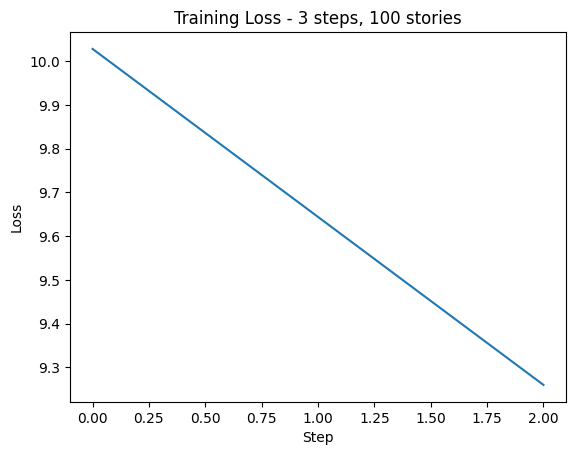

In [398]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss - 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [399]:
from pathlib import Path
import orbax

In [400]:
import os

In [401]:
os.chdir("/tmp")

In [402]:
checkpoint_path = Path("/tmp/small_checkpoint.orbax")

In [403]:
checkpointer = orbax.checkpoint.PyTreeCheckpointer()


In [404]:

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"


In [405]:
checkpoint_path 

PosixPath('/tmp/small_checkpoint.orbax')

In [406]:
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /tmp/small_checkpoint.orbax


### Loading and Running a Pretrained LLM

In [407]:
from helper import MiniGPT, generate_story

In [408]:
model = MiniGPT()

ValueError: Found data on value of type '<class 'list'>' assigned to static attribute 'transformer_blocks' of Pytree type '<class 'helper.MiniGPT'>'. Static attributes should not contain data values. Consider one of the following options:

1. If the attribute is meant to be static, remove the data values of type(s):

  TransformerBlock

2. If the attribute is meant to be data, wrap the value with nnx.data  on assignment:

  _.transformer_blocks = nnx.data(...)

3. Alternatively, annotate the class attribute with nnx.data:

  class MiniGPT(Module):
    transformer_blocks: list = nnx.data()

4. If the container is a list or dict, try using nnx.List(...) or nnx.Dict(...) instead.

5. Disable pytree for this class:

  class MiniGPT(Module, pytree=False):



In [ ]:
# model

### Load the saved checkpoint

In [409]:
import orbax
from orbax import checkpoint
from jax.sharding import SingleDeviceSharding

In [410]:
cpu_device = jax.devices('cpu')[0]
cpu_sharding = SingleDeviceSharding(cpu_device)

In [411]:
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding),
    nnx.state(model)
)

In [412]:
# nnx.state(model)

In [413]:
checkpoint_path = Path.cwd() / "model_checkpoint.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

In [414]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_path = Path("/content/drive/MyDrive/small_checkpoint.orbax")

# Save
checkpointer.save(checkpoint_path, nnx.state(model))

# Restore
restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)
nnx.update(model, restored_state)


ModuleNotFoundError: No module named 'google.colab'

In [415]:
import os
print(os.getcwd())      # current directory
print(os.path.expanduser("~"))  

/tmp
/home/z005657m


In [416]:
from pathlib import Path
import os

# Use home directory — this persists across cells in the same session
checkpoint_path = Path(os.path.expanduser("~")) / "small_checkpoint.orbax"
print(f"Saving to: {checkpoint_path}")

# Save
checkpointer.save(checkpoint_path, nnx.state(model))
print("Saved successfully!")
print(os.listdir(checkpoint_path.parent))  # confirm it's there

Saving to: /home/z005657m/small_checkpoint.orbax


ValueError: Destination /home/z005657m/small_checkpoint.orbax already exists.

In [417]:
# Confirm it exists before restoring
print(checkpoint_path.exists())  # must be True

restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)
nnx.update(model, restored_state)

True


## Run Inference

In [418]:
def create_story(story_prompt, temperature, max_new_tokens):
    return generate_story(model, story_prompt, temperature, max_new_tokens)

In [419]:
create_story("Once upon a time a big bear ", 0.2, 30)

'Once upon a time a big bear たnm Venezuelan Ben Edmund Found Venezuelan Found Venezuelan Found Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan Venezuelan'

In [420]:
import gradio
import gradio as gr

demo = gr.Interface(
    fn=create_story,
    inputs=[
        gr.Textbox(label="Story Prompt"),         
        gr.Slider(
            minimum=0, maximum=1.0, value=0.8, step=0.01, label="Temperature"
        ),
        gr.Slider(minimum=0, maximum=200, value=10, step=1, label="Max Tokens"
        )
    ],
    outputs=["text"]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://e97db7b361512ea86e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
pip install grad